# Step 3: Feature Engineering (Coarse-Classing)

Coarse-classing for PD model variables using helper functions in `src/pd_feature_engineering.py`.


## Variables Covered

1. Discrete: `grade`, `home_ownership`, `addr_state`, `verification_status`, `purpose`, `initial_list_status`  
2. Continuous: `term_int`, `emp_length_int`, `delinq_2yrs`, `inq_last_6mths`, `open_acc`, `pub_rec`, `acc_now_delinq`, `mths_since_issue_d`, `int_rate`, `funded_amnt`, `mths_since_earliest_cr_line`, `total_acc`, `total_rev_hi_lim`, `installment`  
3. Continuous with criteria: imbalance (`annual_inc`, `dti_factor/dti`) and null-aware (`mths_since_last_delinq`, `mths_since_last_record`)


In [29]:
import sys
sys.path.insert(0, '/home/jovyan/work/src')

import pandas as pd
from pyspark.sql import functions as F
from spark_utils import get_spark_session, save_parquet
from pd_feature_engineering import fit_pd_coarse_classing, plot_by_woe, add_all_bin_indicator_columns


## 3.1 Load Train/Test Data


In [30]:
spark = get_spark_session()

train_path = '/home/jovyan/work/data/parquet/accepted_general_prep_train.parquet'
test_path = '/home/jovyan/work/data/parquet/accepted_general_prep_test.parquet'

train_df = spark.read.parquet(train_path)
test_df = spark.read.parquet(test_path)

print(f'Train rows: {train_df.count()}, columns: {len(train_df.columns)}')
print(f'Test rows: {test_df.count()}, columns: {len(test_df.columns)}')


Spark driver memory: 7g
Train rows: 1807770, columns: 156
Test rows: 452931, columns: 156


## 3.2 Ensure Target Column (`good_bad`)


In [31]:
TARGET_COL = 'good_bad'

if TARGET_COL not in train_df.columns:
    train_df = train_df.withColumn(
        TARGET_COL,
        F.when(F.col('loan_status').isin(
            'Charged Off',
            'Default',
            'Does not meet the credit policy. Status:Charged Off',
            'Late (31-120 days)',
        ), F.lit(0)).otherwise(F.lit(1))
    )

if TARGET_COL not in test_df.columns:
    test_df = test_df.withColumn(
        TARGET_COL,
        F.when(F.col('loan_status').isin(
            'Charged Off',
            'Default',
            'Does not meet the credit policy. Status:Charged Off',
            'Late (31-120 days)',
        ), F.lit(0)).otherwise(F.lit(1))
    )

train_df.groupBy(TARGET_COL).count().show()


+--------+-------+
|good_bad|  count|
+--------+-------+
|       1|1575678|
|       0| 232092|
+--------+-------+



## 3.3 Run Coarse-Classing Pipelines


In [32]:
train_fe, test_fe, pipelines, reports, name_mapping, missing_vars = fit_pd_coarse_classing(
    train_df,
    test_df,
    target_col=TARGET_COL,
)

print(f'Pipelines fitted: {len(pipelines)}')
print('Mapped business variable -> resolved column:')
for k, v in name_mapping.items():
    print(f'  {k} -> {v}')

if missing_vars:
    print('Missing variables (not found in dataframe):', missing_vars)

print(f'Train engineered columns: {len(train_fe.columns)}')
print(f'Test engineered columns: {len(test_fe.columns)}')


Pipelines fitted: 24
Mapped business variable -> resolved column:
  grade -> grade
  home_ownership -> home_ownership
  addr_state -> addr_state
  verification_status -> verification_status
  purpose -> purpose
  initial_list_status -> initial_list_status
  term_int -> term_int
  emp_length_int -> emp_length_int
  delinq_2yrs -> delinq_2yrs
  inq_last_6mths -> inq_last_6mths
  open_acc -> open_acc
  pub_rec -> pub_rec
  acc_now_delinq -> acc_now_delinq
  mths_since_issue_d -> mths_since_issue_d
  int_rate -> int_rate
  funded_amnt -> funded_amnt
  mths_since_earliest_cr_line -> mths_since_earliest_cr_line
  total_acc -> total_acc
  total_rev_hi_lim -> total_rev_hi_lim
  installment -> installment
  annual_inc -> annual_inc
  dti_factor -> dti
  mths_since_last_delinq -> mths_since_last_delinq
  mths_since_last_record -> mths_since_last_record
Train engineered columns: 228
Test engineered columns: 228


## 3.4 Example Reports


In [33]:
pipelines["acc_now_delinq"].history_

[{'iter': 0,
  'table':    __order__       bin    n_obs  prop_good  prop_n_obs     n_good     n_bad  \
  0          1  (0, inf]  1807770   0.871614         1.0  1575678.0  232092.0   
  
     prop_n_good  prop_n_bad  WoE  diff_prop_good  diff_WoE  IV_component   IV  
  0          1.0         1.0  0.0             NaN       NaN           0.0  0.0  ,
  'small_bins': [],
  'close_pairs': [],
  'monotonic_break_pairs': [],
  'suggested_pair': None,
  'stop_reason': 'No more merge candidates.'}]

In [34]:
# WoE/IV table examples
example_feats = [ "annual_inc", "dti_factor", "mths_since_last_delinq", "mths_since_last_record" ]
for feat in example_feats:
    resolved = name_mapping.get(feat)
    if resolved in reports:
        print(f'=== {feat} (resolved: {resolved}) ===')
        display(reports[resolved].head(15))


=== annual_inc (resolved: annual_inc) ===


,__order__,bin,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV_component,IV
0,0,"(-inf, 40000]",281747,0.847565,0.155853,238799.0,42948.0,0.151553,0.185047,-0.199675,NaN,NaN,0.006688,0.03169
1,1,"(40000, 45000]",116266,0.852261,0.064315,99089.0,17177.0,0.062887,0.074009,-0.162860,0.004696,0.036815,0.001811,0.03169
2,2,"(45000, 50000]",112763,0.855094,0.062377,96423.0,16340.0,0.061195,0.070403,-0.140178,0.002833,0.022682,0.001291,0.03169
3,3,"(50000, 60048]",303184,0.860695,0.167712,260949.0,42235.0,0.165611,0.181975,-0.094231,0.005601,0.045947,0.001542,0.03169
4,4,"(60048, 72000]",213027,0.868533,0.117840,185021.0,28006.0,0.117423,0.120668,-0.027257,0.007838,0.066975,0.000088,0.03169
5,5,"(72000, 77000]",98209,0.875093,0.054326,85942.0,12267.0,0.054543,0.052854,0.031453,0.006560,0.058709,0.000053,0.03169
6,6,"(77000, 90000]",174976,0.877669,0.096791,153571.0,21405.0,0.097463,0.092226,0.055231,0.002576,0.023779,0.000289,0.03169
7,7,"(90000, 100000]",112528,0.885922,0.062247,99691.0,12837.0,0.063269,0.055310,0.134437,0.008253,0.079205,0.001070,0.03169
8,8,"(100000, 130000]",207642,0.894747,0.114861,185787.0,21855.0,0.117909,0.094165,0.224864,0.008825,0.090427,0.005339,0.03169
9,9,"(130000, inf]",187428,0.909181,0.103679,170406.0,17022.0,0.108148,0.073342,0.388370,0.014434,0.163506,0.013518,0.03169


=== dti_factor (resolved: dti) ===


,__order__,bin,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV_component,IV
0,0,"(-inf, 7.29]",180604,0.902206,0.099904,162942.0,17662.0,0.103411,0.076099,0.306672,NaN,NaN,8.375694e-03,0.040117
1,1,"(7.29, 10.55]",180110,0.898345,0.099631,161801.0,18309.0,0.102687,0.078887,0.263667,0.003860,0.043004,6.275222e-03,0.040117
2,2,"(10.55, 12.53]",136169,0.892758,0.075324,121566.0,14603.0,0.077152,0.062919,0.203923,0.005587,0.059744,2.902345e-03,0.040117
3,3,"(12.53, 13.75]",90678,0.888650,0.050160,80581.0,10097.0,0.051141,0.043504,0.161717,0.004108,0.042206,1.234911e-03,0.040117
4,4,"(13.75, 16.08]",179747,0.883386,0.099430,158786.0,20961.0,0.100773,0.090313,0.109587,0.005264,0.052131,1.146256e-03,0.040117
5,5,"(16.08, 17.82]",134215,0.877361,0.074243,117755.0,16460.0,0.074733,0.070920,0.052366,0.006025,0.057221,1.996584e-04,0.040117
6,6,"(17.82, 19.66]",137352,0.871447,0.075979,119695.0,17657.0,0.075964,0.076078,-0.001493,0.005914,0.053858,1.693531e-07,0.040117
7,7,"(19.66, 22.98]",225141,0.863490,0.124541,194407.0,30734.0,0.123380,0.132422,-0.070723,0.007957,0.069230,6.394552e-04,0.040117
8,8,"(22.98, 25.33]",136473,0.852923,0.075492,116401.0,20072.0,0.073874,0.086483,-0.157592,0.010567,0.086869,1.987130e-03,0.040117
9,9,"(25.33, 30.5]",225016,0.841216,0.124472,189287.0,35729.0,0.120131,0.153943,-0.248005,0.011708,0.090414,8.385745e-03,0.040117


=== mths_since_last_delinq (resolved: mths_since_last_delinq) ===


,__order__,bin,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV_component,IV
0,0,"(-inf, 19]",257281,0.855730,0.142320,220163.0,37118.0,0.139726,0.159928,-0.135041,NaN,NaN,0.002728,0.005024
1,1,"(19, 34]",211332,0.865856,0.116902,182983.0,28349.0,0.116130,0.122146,-0.050506,0.010126,0.084535,0.000304,0.005024
2,2,"(34, 49]",177556,0.870435,0.098218,154551.0,23005.0,0.098085,0.099120,-0.010495,0.004580,0.040011,0.000011,0.005024
3,3,"(49, inf]",235108,0.868605,0.130054,204216.0,30892.0,0.129605,0.133102,-0.026626,0.001830,0.016132,0.000093,0.005024
4,4,MISSING,926493,0.878328,0.512506,813765.0,112728.0,0.516454,0.485704,0.061387,0.009723,0.088013,0.001888,0.005024


=== mths_since_last_record (resolved: mths_since_last_record) ===


,__order__,bin,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV_component,IV
0,0,"(-inf, 69]",120732,0.836473,0.066785,100989.0,19743.0,0.064092,0.085065,-0.283094,NaN,NaN,0.005937,0.011675
1,1,"(69, inf]",166714,0.848159,0.092221,141400.0,25314.0,0.089739,0.109069,-0.195072,0.011687,0.088023,0.003771,0.011675
2,2,MISSING,1520324,0.876977,0.840994,1333289.0,187035.0,0.846168,0.805866,0.048801,0.028818,0.243873,0.001967,0.011675


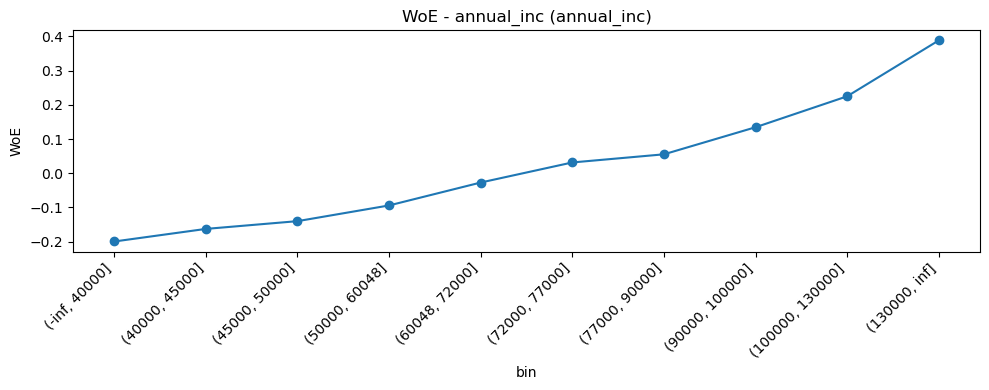

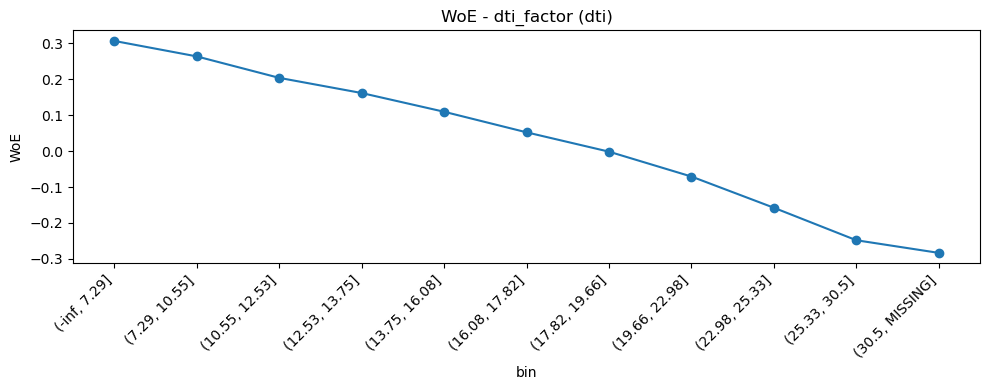

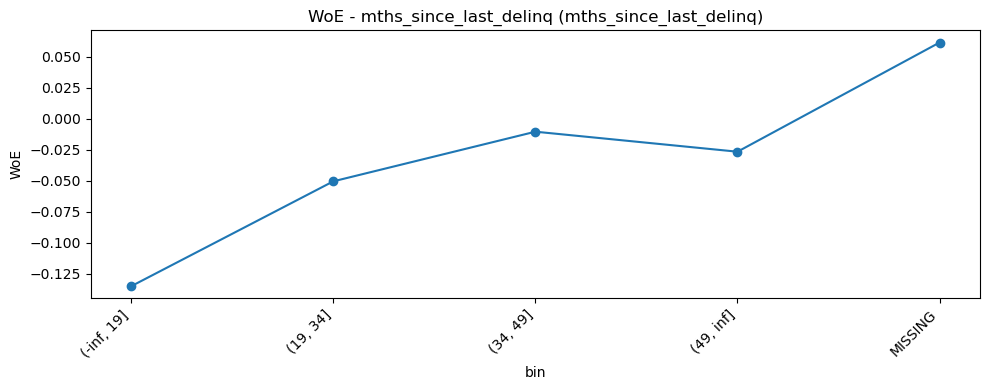

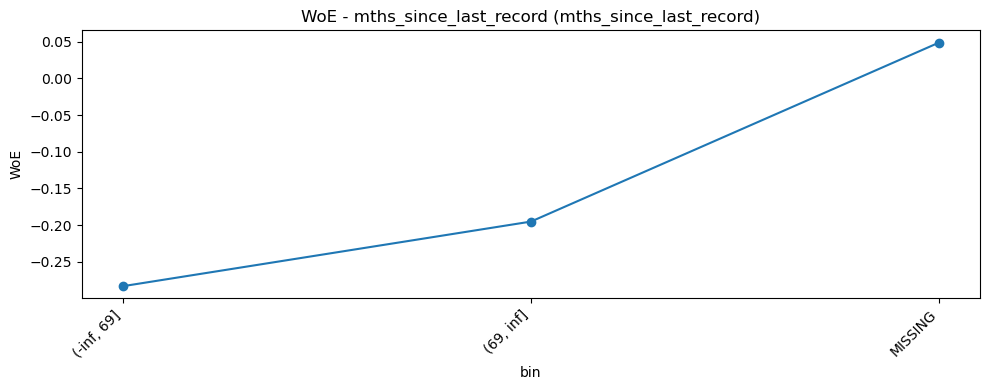

In [35]:
# Optional visual checks
for feat in ["annual_inc", "dti_factor", "mths_since_last_delinq", "mths_since_last_record"]:
    resolved = name_mapping.get(feat)
    if resolved in reports:
        plot_by_woe(reports[resolved], title=f'WoE - {feat} ({resolved})')


In [36]:
train_fe_bins = add_all_bin_indicator_columns(train_fe, pipelines, drop_grp_cols=False)
test_fe_bins = add_all_bin_indicator_columns(test_fe, pipelines, drop_grp_cols=False)

In [37]:
train_fe.select("addr_state", *[c for c in train_fe.columns if c.startswith("addr_state")]).show(20, truncate=False)

+----------+----------+--------------------+----------------------------------------------------+---------------------+
|addr_state|addr_state|addr_state__base_grp|addr_state_grp                                      |addr_state_woe       |
+----------+----------+--------------------+----------------------------------------------------+---------------------+
|AR        |AR        |AR                  |LA | OK | AR | MS | AL | IA | NM | NY | NV          |-0.13932467779184698 |
|TN        |TN        |TN                  |TN | KY | MI | MN | VA | AK                         |-0.016477076476022184|
|VA        |VA        |VA                  |TN | KY | MI | MN | VA | AK                         |-0.016477076476022184|
|CA        |CA        |CA                  |NJ | CA                                             |-0.03133883133779203 |
|TX        |TX        |TX                  |AZ | OH | TX | DE                                   |0.008553826584255114 |
|KS        |KS        |KS               

## 3.5 Save Outputs


In [38]:
drop_cols_train = [
    c for c in train_fe_bins.columns
    if c.endswith("_grp") or c.endswith("_woe") or c.endswith("__base_grp")
]
drop_cols_test = [
    c for c in test_fe_bins.columns
    if c.endswith("_grp") or c.endswith("_woe") or c.endswith("__base_grp")
]

train_fe_bins = train_fe_bins.drop(*drop_cols_train)
test_fe_bins = test_fe_bins.drop(*drop_cols_test)

In [39]:
new_cols_train = [c for c in train_fe_bins.columns if c not in train_df.columns]
new_cols_test = [c for c in test_fe_bins.columns if c not in test_df.columns]

print("New columns in train_fe:")
for c in new_cols_train:
    print(c)

print("\nNew columns in test_fe:")
for c in new_cols_test:
    print(c)

New columns in train_fe:
grade_B
grade_A|MISSING
grade_D
grade_F|G|E
grade_C
home_ownership_NONE|OTHER|RENT
home_ownership_MORTGAGE|MISSING|ANY
home_ownership_OWN
addr_state_AZ|OH|TX|DE
addr_state_PA|IN|MD|NC|MO|HI
addr_state_LA|OK|AR|MS|AL|IA|NM|NY|NV
addr_state_SD|FL
addr_state_NJ|CA
addr_state_RI|GA|WI|NE|UT|MA
addr_state_WY|IL|MT|CT|ND|KS|WA
addr_state_TN|KY|MI|MN|VA|AK
addr_state_SC|CO|DC|OR|MISSING|ME|ID|VT|NH|WV
verification_status_SourceVerified
verification_status_NotVerified|MISSING
verification_status_Verified
purpose_wedding|other|medical|vacation|house|major_purchase
purpose_credit_card|MISSING|car
purpose_home_improvement
purpose_debt_consolidation|moving|renewable_energy|educational|small_business
initial_list_status_w|MISSING
initial_list_status_f
term_int_(36,60]
term_int_(60,MISSING]
emp_length_int_(10,inf]
emp_length_int_(1,2]
emp_length_int_(0,1]
emp_length_int_(2,6]
emp_length_int_(6,10]
delinq_2yrs_(0,1]
delinq_2yrs_(1,inf]
inq_last_6mths_(1,2]
inq_last_6mths_(2,i

In [40]:
full_baseline = train_fe_bins.unionByName(test_fe_bins, allowMissingColumns=True)

save_parquet(train_fe_bins, '/home/jovyan/work/data/parquet/features_pd_train.parquet')
save_parquet(test_fe_bins, '/home/jovyan/work/data/parquet/features_pd_test.parquet')
save_parquet(full_baseline, '/home/jovyan/work/data/parquet/features_baseline.parquet')

# Save WoE reports for auditability
for resolved_col, rep in reports.items():
    rep.to_csv(f'/home/jovyan/work/outputs/tables/woe_report_{resolved_col}.csv', index=False)

print('Saved parquet features and WoE report CSV files.')


Saved to /home/jovyan/work/data/parquet/features_pd_train.parquet
Saved to /home/jovyan/work/data/parquet/features_pd_test.parquet
Saved to /home/jovyan/work/data/parquet/features_baseline.parquet
Saved parquet features and WoE report CSV files.
